In [26]:
import os
import math
import time
import random
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import json


import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, random_split, Subset
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from scipy import ndimage
from PIL import Image
from torchvision.transforms import functional as F
from torchvision.transforms import InterpolationMode
from datetime import datetime

print("torch:", torch.__version__)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

FAST_MODE = True

def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

results_columns = [
    "experiment_id", "task", "dataset", "seed", "model_summary",
    "optimizer", "lr", "epochs_trained", "best_val_accuracy", "best_val_loss",
    "test_accuracy", "presision", "recal", "mean_iou", "notes"
]
results_df = pd.DataFrame(columns=results_columns)


results_df = pd.DataFrame(columns=results_columns)

print("Текущая рабочая директория:", os.getcwd())
print("Файлы в текущей директории:", os.listdir('.'))

from pathlib import Path

ARTIFACTS_DIR = Path("artifacts")
FIGURES_DIR = ARTIFACTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"ARTIFACTS_DIR: {ARTIFACTS_DIR.absolute()}")
print(f"FIGURES_DIR: {FIGURES_DIR.absolute()}")

FAST_MODE_RES = True

EPOCHS_HEAD = 3 if FAST_MODE else 8
EPOCHS_FT   = 3 if FAST_MODE else 8

RANDOM_STATE = 42

seed_everything(RANDOM_STATE)

torch: 2.11.0+cu126
device: cuda
Текущая рабочая директория: d:\ai__course\ai_course\homeworks\HW10-11
Файлы в текущей директории: ['artifacts', 'data', 'HW10-11.ipynb']
ARTIFACTS_DIR: d:\ai__course\ai_course\homeworks\HW10-11\artifacts
FIGURES_DIR: d:\ai__course\ai_course\homeworks\HW10-11\artifacts\figures


In [27]:
DATA_DIR = "./data"

BATCH_SIZE_CNN = 64
IMG_SIZE = 224

In [28]:
CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD = (0.2675, 0.2565, 0.2761)


train_tf_cnn = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4), 
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),  
])

eval_tf_cnn = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

train_tf_resnet = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])  

eval_tf_resnet = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

def load_cifar100_cnn(data_dir: str = DATA_DIR):
    ds_train_aug  = torchvision.datasets.CIFAR100(root=data_dir, train=True, download=True, transform=train_tf_cnn)
    ds_train_eval = torchvision.datasets.CIFAR100(root=data_dir, train=True, download=True, transform=eval_tf_cnn)
    ds_test = torchvision.datasets.CIFAR100(root=data_dir, train=False, download=True, transform=eval_tf_cnn)
    return ds_train_aug, ds_train_eval, ds_test

def load_cifar100_resnet(data_dir: str = DATA_DIR):
    
    ds_train_aug  = torchvision.datasets.CIFAR100(root=data_dir, train=True, download=True, transform=train_tf_resnet)
    ds_train_eval = torchvision.datasets.CIFAR100(root=data_dir, train=True, download=True, transform=eval_tf_resnet)
    ds_test = torchvision.datasets.CIFAR100(root=data_dir, train=False, download=True, transform=eval_tf_resnet)
    return ds_train_aug, ds_train_eval, ds_test

ds_train_aug_cnn, ds_train_eval_cnn, ds_test_cnn = load_cifar100_cnn()
ds_train_aug_resnet, ds_train_eval_resnet, ds_test_resnet = load_cifar100_resnet()

d:\ai__course\ai_course\homeworks\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [29]:
def make_loaders_cnn(
    ds_train_aug,
    ds_train_eval,
    ds_test,
    batch_size: int = BATCH_SIZE_CNN,
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE,  
):
    n_total = len(ds_train_aug)
    n_val = int(n_total * val_ratio)

    rng = np.random.RandomState(seed)
    indices = np.arange(n_total)
    rng.shuffle(indices)

    val_idx = indices[:n_val]
    train_idx = indices[n_val:]

    ds_train = Subset(ds_train_aug, train_idx)
    ds_val   = Subset(ds_train_eval, val_idx)

    if fast_mode:
        train_idx2 = rng.choice(len(ds_train), size=min(4000, len(ds_train)), replace=False)
        val_idx2   = rng.choice(len(ds_val), size=min(1000, len(ds_val)), replace=False)
        test_idx2  = rng.choice(len(ds_test), size=min(1000, len(ds_test)), replace=False)

        ds_train = Subset(ds_train, train_idx2)
        ds_val   = Subset(ds_val, val_idx2)
        ds_test_small = Subset(ds_test, test_idx2)
    else:
        ds_test_small = ds_test

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=8, pin_memory=True)
    test_loader  = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=8, pin_memory=True)

    return train_loader, val_loader, test_loader


def make_loaders_no_aug(ds_train_eval, ds_test, batch_size=64, val_ratio=0.2, seed=42, fast_mode: bool = FAST_MODE): 
    n_total = len(ds_train_eval)
    n_val = int(n_total * val_ratio)
    
    rng = np.random.RandomState(seed)
    indices = np.arange(n_total)
    rng.shuffle(indices)
    
    ds_train = Subset(ds_train_eval, indices[n_val:])
    ds_val = Subset(ds_train_eval, indices[:n_val])
    
    if fast_mode:
        ds_train = Subset(ds_train, rng.choice(len(ds_train), 4000, replace=False))
        ds_val = Subset(ds_val, rng.choice(len(ds_val), 1000, replace=False))
        ds_test = Subset(ds_test, rng.choice(len(ds_test), 1000, replace=False))
    
    return (DataLoader(ds_train, batch_size, shuffle=True, num_workers=8, pin_memory=True),
            DataLoader(ds_val, batch_size, shuffle=False, num_workers=8, pin_memory=True),
            DataLoader(ds_test, batch_size, shuffle=False, num_workers=8, pin_memory=True))


def make_loaders_resnet(
    ds_train_aug,
    ds_train_eval,
    ds_test,
    batch_size: int = 128, 
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE_RES,
):
    n_total = len(ds_train_aug)
    n_val = int(n_total * val_ratio)

    rng = np.random.RandomState(seed)
    indices = np.arange(n_total)
    rng.shuffle(indices)

    val_idx = indices[:n_val]
    train_idx = indices[n_val:]

    ds_train = Subset(ds_train_aug, train_idx)
    ds_val   = Subset(ds_train_eval, val_idx)

    if fast_mode:
        train_idx2 = rng.choice(len(ds_train), size=min(4000, len(ds_train)), replace=False)
        val_idx2   = rng.choice(len(ds_val), size=min(1000, len(ds_val)), replace=False)
        test_idx2  = rng.choice(len(ds_test), size=min(1000, len(ds_test)), replace=False)

        ds_train = Subset(ds_train, train_idx2)
        ds_val   = Subset(ds_val, val_idx2)
        ds_test_small = Subset(ds_test, test_idx2)
    else:
        ds_test_small = ds_test

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=8, pin_memory=True)
    test_loader  = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=8, pin_memory=True)

    return train_loader, val_loader, test_loader


train_loader_cnn, val_loader_cnn, test_loader_cnn = make_loaders_cnn(
    ds_train_aug_cnn, ds_train_eval_cnn, ds_test_cnn
)

x, y = next(iter(train_loader_cnn))
print("CNN - x:", x.shape, x.dtype)
print("CNN - y:", y.shape, y.dtype)

train_loader_resnet, val_loader_resnet, test_loader_resnet = make_loaders_resnet(
    ds_train_aug_resnet, ds_train_eval_resnet, ds_test_resnet, 
    batch_size=64,
    fast_mode=FAST_MODE_RES
)

x, y = next(iter(train_loader_resnet))
print("ResNet - x:", x.shape, x.dtype)
print("ResNet - y:", y.shape, y.dtype)

CNN - x: torch.Size([64, 3, 32, 32]) torch.float32
CNN - y: torch.Size([64]) torch.int64
ResNet - x: torch.Size([64, 3, 224, 224]) torch.float32
ResNet - y: torch.Size([64]) torch.int64


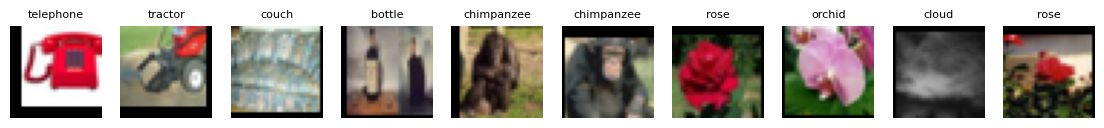

In [30]:
class_names = ds_train_eval_cnn.classes

def denorm_cifar(x: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(CIFAR100_MEAN).view(3, 1, 1)
    std = torch.tensor(CIFAR100_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10, save_path=None) -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_cifar(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

save_path = FIGURES_DIR / "augmentations_preview.png"
show_images(train_loader_cnn, n=10, save_path=save_path)

In [31]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 100):
        super().__init__()
        self.features = nn.Sequential(

            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2), 
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2), 
        )
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


cnn = SimpleCNN(100).to(DEVICE)
print(cnn)
print("Trainable params:", count_params(cnn))

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), paddi

In [32]:
with torch.no_grad():
    x0 = torch.randn(2, 3, 32, 32).to(DEVICE)
    y0 = cnn(x0)
print("Input:", x0.shape, "Output logits:", y0.shape)

Input: torch.Size([2, 3, 32, 32]) Output logits: torch.Size([2, 100])


In [ ]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак проблем с LR/стабильностью. Останавливаем обучение.")
            break

    return history

def plot_history(history, title="Training History"):
    """Визуализация кривых обучения"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    

    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].plot(history['val_loss'], label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss Curves')
    axes[0].legend()
    axes[0].grid(True)
    

    axes[1].plot(history['train_acc'], label='Train Acc')
    axes[1].plot(history['val_acc'], label='Val Acc')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy Curves')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.suptitle(title)
    plt.tight_layout()
    return fig 
    


Experiment C1 | lr=0.001 weight_decay=0.0 epochs=10
Trainable params: 1330084
Epoch 01/10 | train loss 4.4858, acc 0.026 | val loss 4.2583, acc 0.042 | 85.2s
Epoch 02/10 | train loss 4.2434, acc 0.045 | val loss 4.1807, acc 0.046 | 76.0s
Epoch 03/10 | train loss 4.0900, acc 0.053 | val loss 4.1043, acc 0.062 | 35.2s
Epoch 04/10 | train loss 3.9795, acc 0.066 | val loss 3.8960, acc 0.085 | 58.8s
Epoch 05/10 | train loss 3.8585, acc 0.077 | val loss 3.8599, acc 0.092 | 66.9s
Epoch 06/10 | train loss 3.7693, acc 0.098 | val loss 3.9375, acc 0.082 | 35.0s
Epoch 07/10 | train loss 3.7016, acc 0.097 | val loss 3.7861, acc 0.109 | 34.1s
Epoch 08/10 | train loss 3.6316, acc 0.117 | val loss 3.7544, acc 0.111 | 77.7s
Epoch 09/10 | train loss 3.5100, acc 0.124 | val loss 3.6256, acc 0.141 | 86.0s
Epoch 10/10 | train loss 3.4427, acc 0.132 | val loss 3.5433, acc 0.135 | 81.4s

Experiment C2 | lr=0.001 weight_decay=0.0 epochs=10
Trainable params: 1330084
Epoch 01/10 | train loss 4.4619, acc 0.029

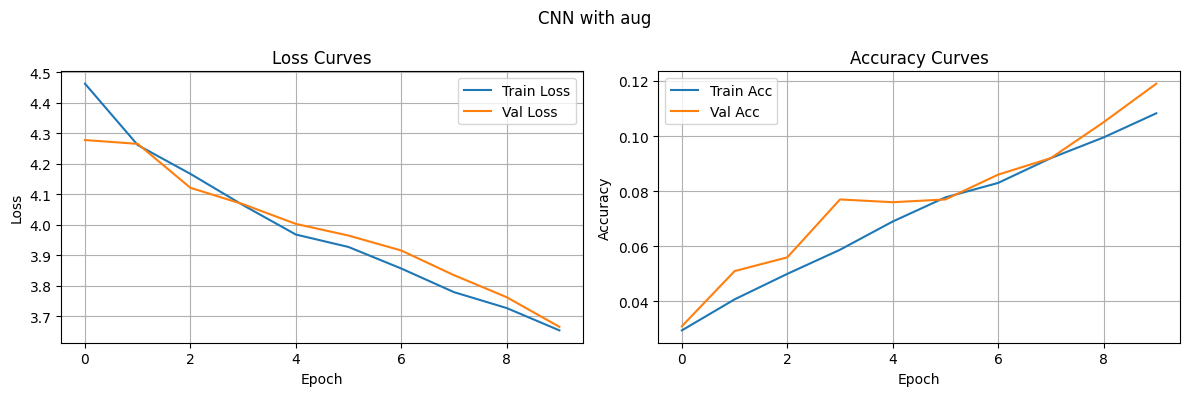

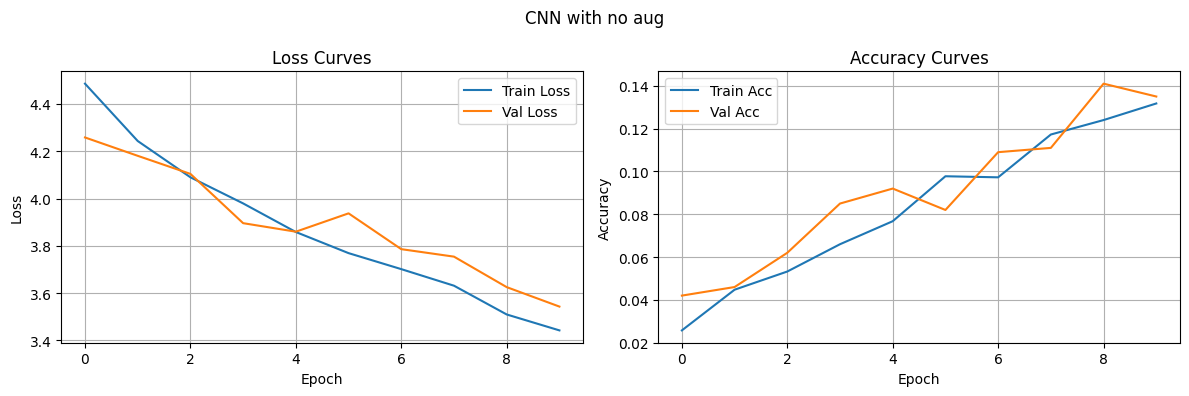

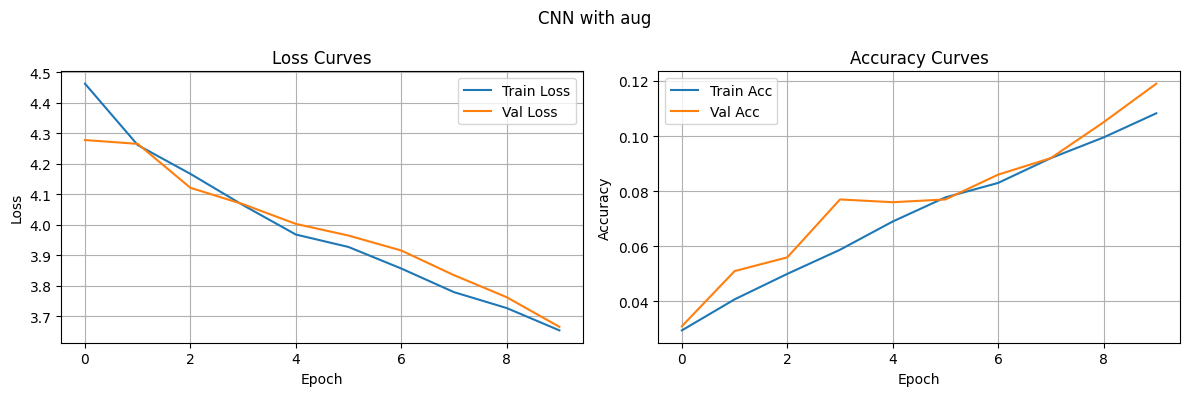

In [34]:
criterion = nn.CrossEntropyLoss()

def run_experiment(exp_id: str, model: nn.Module, type_of_train_data: str, lr: float = 1e-3, weight_decay: float = 0.0, epochs: int = 7, fast_mode: bool = FAST_MODE):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    print("\n" + "=" * 80)
    print(f"Experiment {exp_id} | lr={lr} weight_decay={weight_decay} epochs={epochs}")
    print("Trainable params:", count_params(model))

    if type_of_train_data == 'aug':
        train_loader, val_loader, _ = make_loaders_cnn(ds_train_aug_cnn, ds_train_eval_cnn, ds_test_cnn)
    else:
        train_loader, val_loader, _ = make_loaders_no_aug(ds_train_eval_cnn, ds_test_cnn)

    hist = fit(model, train_loader, val_loader, optimizer, criterion, epochs=epochs, verbose=True)
    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")
 
    result_history =  {"exp_id": exp_id, "model": model, "history": hist, "best_val_acc": best_val_acc}

    return result_history

res_no_aug = run_experiment("C1", SimpleCNN(100), 'no_aug', epochs=10)
plot_history(res_no_aug["history"], title="CNN with no aug")

res_aug = run_experiment("C2", SimpleCNN(100), 'aug', epochs=10)
plot_history(res_aug["history"], title="CNN with aug")

In [35]:
def get_resnet18_weights():
    try:
        w = ResNet18_Weights.DEFAULT
        return w
    except Exception as e:
        print("Не удалось получить веса ResNet18_Weights.DEFAULT. Причина:", repr(e))
        return None

weights = get_resnet18_weights()
print("weights:", weights)

weights: ResNet18_Weights.IMAGENET1K_V1


In [36]:
def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def build_resnet18(num_classes: int = 100, weights=weights) -> nn.Module:
    try:
        model = resnet18(weights=weights)
    except Exception as e:
        print("Не удалось загрузить предобученные веса. Переходим на weights=None. Причина:", repr(e))
        model = resnet18(weights=None)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(module: nn.Module, flag: bool) -> None:
    for p in module.parameters():
        p.requires_grad = flag

model = build_resnet18(num_classes=100, weights=weights).to(DEVICE)
print(model)
print("Trainable params:", count_trainable_params(model))

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Trainable params (head-only): 51300

Phase 1: head-only training
Epoch 01/3 | train loss 4.2855, acc 0.075 | val loss 3.6985, acc 0.206 | 89.3s
Epoch 02/3 | train loss 3.3084, acc 0.289 | val loss 3.1400, acc 0.290 | 44.9s
Epoch 03/3 | train loss 2.7334, acc 0.397 | val loss 2.7731, acc 0.349 | 37.1s


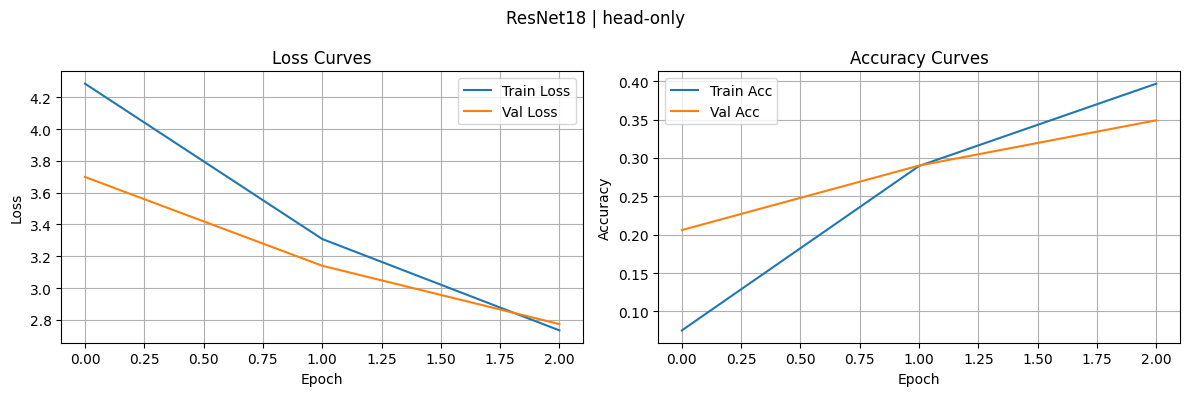

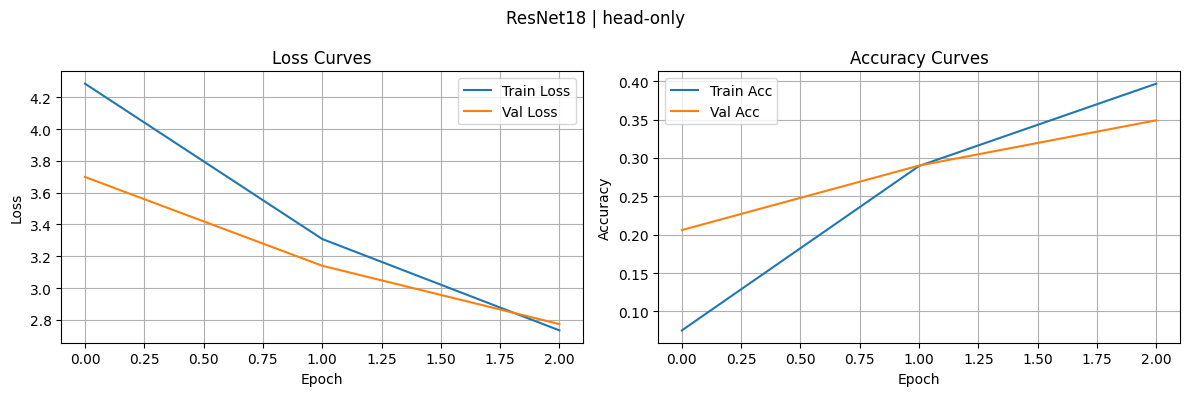

In [37]:
criterion = nn.CrossEntropyLoss()

model_head = build_resnet18(num_classes=100, weights=weights).to(DEVICE)

set_requires_grad(model_head, False)

set_requires_grad(model_head.fc, True)

print("Trainable params (head-only):", count_trainable_params(model_head))

optimizer_head = torch.optim.Adam(model_head.fc.parameters(), lr=1e-3)

print("\n" + "=" * 80)
print("Phase 1: head-only training")
hist_head = fit(model_head, train_loader_resnet, val_loader_resnet, optimizer_head, criterion, epochs=EPOCHS_HEAD, verbose=True)
plot_history(hist_head, title="ResNet18 | head-only")

Trainable params (layer4+fc): 8445028

Phase 2: fine-tuning layer4 + fc
Epoch 01/3 | train loss 2.0830, acc 0.481 | val loss 2.0281, acc 0.442 | 37.0s
Epoch 02/3 | train loss 1.3657, acc 0.647 | val loss 1.8743, acc 0.482 | 37.0s
Epoch 03/3 | train loss 1.0163, acc 0.741 | val loss 1.7602, acc 0.495 | 37.1s


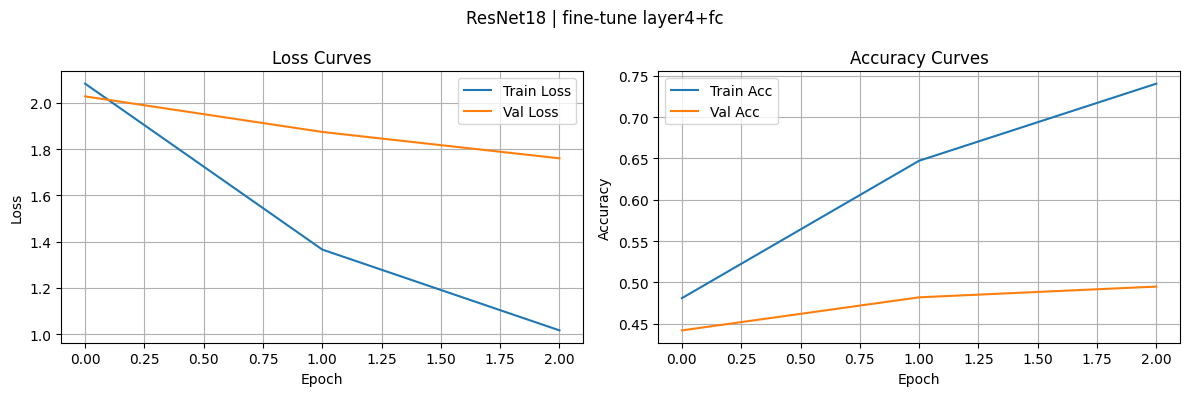

In [38]:
set_requires_grad(model_head.layer4, True)
set_requires_grad(model_head.fc, True)

print("Trainable params (layer4+fc):", count_trainable_params(model_head))

params = [
    {"params": model_head.layer4.parameters(), "lr": 1e-4},
    {"params": model_head.fc.parameters(), "lr": 1e-3},
]

optimizer_ft = torch.optim.Adam(params, weight_decay=1e-4)

print("\n" + "=" * 80)
print("Phase 2: fine-tuning layer4 + fc")
hist_ft = fit(model_head, train_loader_resnet, val_loader_resnet, optimizer_ft, criterion, epochs=EPOCHS_FT, verbose=True)
plot_history(hist_ft, title="ResNet18 | fine-tune layer4+fc")
plt.savefig(FIGURES_DIR / "classification_curves_best.png", dpi=150, bbox_inches="tight")

In [39]:
test_loss, test_acc = evaluate(model_head, test_loader_resnet, criterion)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss: 1.6196
Test accuracy: 0.5490


In [40]:
plot_history(hist_ft, title="ResNet18 | fine-tune layer4+fc")

plt.savefig(FIGURES_DIR / "classification_curves_best.png", dpi=150, bbox_inches="tight")
plt.close()

print(f"График сохранен в {FIGURES_DIR / 'classification_curves_best.png'}")

График сохранен в artifacts\figures\classification_curves_best.png


In [41]:
best_config = {
    "dataset": "CIFAR100",
    "seed": RANDOM_STATE,
    "fast_mode": FAST_MODE,
    
    "model_type": "ResNet18_pretrained",
    "model_summary": "Pretrained ResNet18 with fine-tuning of layer4 and fc",
    "num_classes": 100,
    "pretrained": True,
    
    "trainable_layers": ["layer4", "fc"],
    "frozen_layers": ["conv1", "bn1", "layer1", "layer2", "layer3"],
    
    "transforms_train": {
        "name": "train_tf_resnet",
        "resize_size": 256,
        "crop_size": 224,
        "scale": [0.7, 1.0],
        "horizontal_flip_prob": 0.5,
        "normalize_mean": [0.5071, 0.4867, 0.4408],
        "normalize_std": [0.2675, 0.2565, 0.2761]
    },
    "transforms_eval": {
        "name": "eval_tf_resnet",
        "resize_size": 256,
        "crop_size": 224,
        "normalize_mean": [0.5071, 0.4867, 0.4408],
        "normalize_std": [0.2675, 0.2565, 0.2761]
    },
    
    "optimizer": "Adam",
    "optimizer_params": {
        "layer4": {"lr": 1e-4, "weight_decay": 1e-4},
        "fc": {"lr": 1e-3, "weight_decay": 1e-4}
    },
    
    "criterion": "CrossEntropyLoss",
    "epochs_trained": EPOCHS_FT,
    "batch_size": 64,
    
    "best_val_accuracy": max(hist_ft["val_acc"]),
    "best_val_loss": min(hist_ft["val_loss"]),
    "test_accuracy": None,
    "test_loss": None,  
    

    "notes": "ResNet18 with pretrained weights, fine-tuning layer4 and fc on CIFAR100",
    "date": time.strftime("%Y-%m-%d %H:%M:%S")
}

config_path = ARTIFACTS_DIR / "best_classifier_config.json"
with open(config_path, "w") as f:
    json.dump(best_config, f, indent=2)
print(f"Конфиг сохранен: {config_path}")

Конфиг сохранен: artifacts\best_classifier_config.json


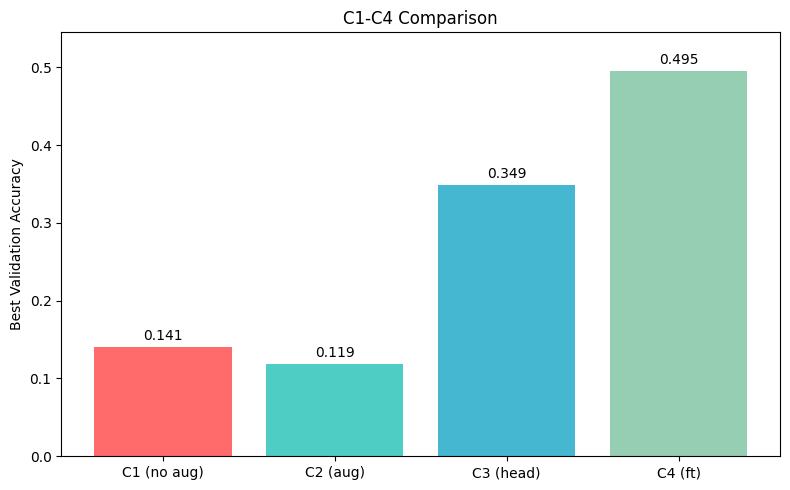

In [42]:
exp_names = ["C1 (no aug)", "C2 (aug)", "C3 (head)", "C4 (ft)"]
best_accs = [
    max(res_no_aug["history"]["val_acc"]),
    max(res_aug["history"]["val_acc"]),
    max(hist_head["val_acc"]),
    max(hist_ft["val_acc"])
]

plt.figure(figsize=(8, 5))
bars = plt.bar(exp_names, best_accs, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
plt.ylim(0, max(best_accs) + 0.05)
plt.ylabel("Best Validation Accuracy")
plt.title("C1-C4 Comparison")

for bar, val in zip(bars, best_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "classification_compare.png")
plt.show()
plt.close()

In [66]:
def save_classification_results(results_list, exp_id, task, dataset, seed, 
                                 model_summary, optimizer, lr, epochs,
                                 history, notes, test_acc=None, test_loss=None):
    
    results_list.append({
        "experiment_id": exp_id,
        "task": task,
        "dataset": dataset,
        "seed": seed,
        "model_summary": model_summary,
        "optimizer": optimizer,
        "lr": lr,
        "epochs_trained": epochs,
        "best_val_accuracy": max(history["val_acc"]),
        "best_val_loss": min(history["val_loss"]),
        "test_accuracy": test_acc,
        "test_loss": test_loss,
        "precision": None,
        "recall": None,
        "mean_iou": None,
        "notes": notes,
    })
    return results_list


def save_segmentation_results(results_list, exp_id, task, dataset, seed,
                               model_summary, postprocess_desc, 
                               metrics, notes):
    
    results_list.append({
        "experiment_id": exp_id,
        "task": task,
        "dataset": dataset,
        "seed": seed,
        "model_summary": model_summary,
        "optimizer": None,
        "lr": None,
        "epochs_trained": None,
        "best_val_accuracy": None,
        "best_val_loss": None,
        "test_accuracy": None,
        "test_loss": None,
        "precision": metrics.get("precision"),
        "recall": metrics.get("recall"),
        "mean_iou": metrics.get("mean_iou"),
        "notes": f"{postprocess_desc} | {notes}",
    })
    return results_list


def save_runs_csv(results_list, output_path):
    """
    Сохраняет результаты в CSV файл
    """
    df = pd.DataFrame(results_list)
    df.to_csv(output_path, index=False)
    print(f"Results saved to {output_path}")
    return df


def save_best_model_config(model, config, output_path):
    with open(output_path, "w") as f:
        json.dump(config, f, indent=2)
    print(f"Config saved to {output_path}")

results = []

results = save_classification_results(
    results, "C1", "classification", "CIFAR100", RANDOM_STATE,
    "SimpleCNN (no aug)", "Adam", 0.001, 10,
    res_no_aug["history"],
    "Simple CNN without augmentations"
)

results = save_classification_results(
    results, "C2", "classification", "CIFAR100", RANDOM_STATE,
    "SimpleCNN (with aug)", "Adam", 0.001, 10,
    res_aug["history"],
    "Simple CNN with augmentations"
)

results = save_classification_results(
    results, "C3", "classification", "CIFAR100", RANDOM_STATE,
    "ResNet18 (head-only)", "Adam", 0.001, EPOCHS_HEAD,
    hist_head,
    "Pretrained ResNet18, backbone frozen"
)

results = save_classification_results(
    results, "C4", "classification", "CIFAR100", RANDOM_STATE,
    "ResNet18 (fine-tune)", "Adam", "layer4:1e-4, fc:1e-3", EPOCHS_FT,
    hist_ft, test_acc, test_loss,
    "Pretrained ResNet18, fine-tuning layer4 and fc"
)

best_model = model_head
best_model_path = ARTIFACTS_DIR / "best_classifier.pt"
torch.save(best_model.state_dict(), best_model_path)
print(save_runs_csv(results,ARTIFACTS_DIR / "runs.csv"))

Results saved to artifacts\runs.csv
  experiment_id            task   dataset  seed         model_summary  \
0            C1  classification  CIFAR100    42    SimpleCNN (no aug)   
1            C2  classification  CIFAR100    42  SimpleCNN (with aug)   
2            C3  classification  CIFAR100    42  ResNet18 (head-only)   
3            C4  classification  CIFAR100    42  ResNet18 (fine-tune)   

  optimizer                    lr  epochs_trained  best_val_accuracy  \
0      Adam                 0.001              10              0.141   
1      Adam                 0.001              10              0.119   
2      Adam                 0.001               3              0.349   
3      Adam  layer4:1e-4, fc:1e-3               3              0.495   

   best_val_loss  test_accuracy  \
0       3.543305            NaN   
1       3.665617            NaN   
2       2.773102            NaN   
3       1.760210       1.619635   

                                        test_loss precision r

ДОБАВИТЬ ПРИМЕРЫ ИЗОБРАЖЕНИЙ, ВСЕ ЧТО НАДО ПОСОХРАНЯТЬ, ЧАСТЬ Б

ЧАСТЬ B

In [44]:
import os
import shutil
from torchvision.datasets.utils import download_and_extract_archive

OXFORD_URL = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz"
OXFORD_ANNOTATIONS_URL = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz"

def ensure_oxford(root: str) -> str:
    oxford_root = os.path.join(root, "oxford-iiit-pet")

    if os.path.isdir(oxford_root):
        img_dir = os.path.join(oxford_root, "images")
        mask_dir = os.path.join(oxford_root, "annotations", "trimaps")
        if os.path.isdir(img_dir) and os.path.isdir(mask_dir):
            imgs = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]
            if len(imgs) > 0:
                print(f"Датасет уже есть в {oxford_root}")
                return oxford_root
    
    os.makedirs(root, exist_ok=True)
    
    for arch in ["images.tar.gz", "annotations.tar.gz"]:
        arch_path = os.path.join(root, arch)
        if os.path.exists(arch_path):
            print(f"Удаляем поврежденный архив: {arch_path}")
            os.remove(arch_path)
    
    print("Скачиваем изображения...")
    download_and_extract_archive(OXFORD_URL, download_root=root, filename="images.tar.gz", remove_finished=True)
    
    print("Скачиваем аннотации...")
    download_and_extract_archive(OXFORD_ANNOTATIONS_URL, download_root=root, filename="annotations.tar.gz", remove_finished=True)
    
    os.makedirs(oxford_root, exist_ok=True)

    if os.path.exists(os.path.join(root, "images")):
        if os.path.exists(os.path.join(oxford_root, "images")):
            shutil.rmtree(os.path.join(oxford_root, "images"))
        shutil.move(os.path.join(root, "images"), os.path.join(oxford_root, "images"))
    
    if os.path.exists(os.path.join(root, "annotations")):
        if os.path.exists(os.path.join(oxford_root, "annotations")):
            shutil.rmtree(os.path.join(oxford_root, "annotations"))
        shutil.move(os.path.join(root, "annotations"), os.path.join(oxford_root, "annotations"))
    
    print(f"Датасет загружен в: {oxford_root}")
    return oxford_root

data_dir = "./data"
oxford_root = ensure_oxford(data_dir)

Датасет уже есть в ./data\oxford-iiit-pet


In [45]:
import os
import numpy as np
from PIL import Image
import torch

class OxfordIIIPetsDataset(torch.utils.data.Dataset):
    def __init__(self, root: str):
        self.root = root
        self.img_dir = os.path.join(root, "images")
        self.mask_dir = os.path.join(root, "annotations", "trimaps")

        all_imgs = sorted([f for f in os.listdir(self.img_dir) if f.lower().endswith(".jpg") and not f.startswith('._')])
        self.imgs = []
        self.masks = []
        
        for img_file in all_imgs:
            base_name = os.path.splitext(img_file)[0]
            mask_file = base_name + ".png"
            mask_path = os.path.join(self.mask_dir, mask_file)
            
            if os.path.exists(mask_path) and not mask_file.startswith('._'):
                self.imgs.append(img_file)
                self.masks.append(mask_file)

        if len(self.imgs) == 0:
            raise RuntimeError("Похоже, структура Oxford-IIIT-Pets повреждена или не распакована полностью.")

    def __len__(self) -> int:
        return len(self.imgs)

    def __getitem__(self, idx: int):
        img_path = os.path.join(self.img_dir, self.imgs[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)
        
        if img.size != mask.size:
            mask = mask.resize(img.size, Image.NEAREST)

        mask_np = np.array(mask)
        gt = (mask_np == 1).astype(np.uint8)

        return img, gt

dataset = OxfordIIIPetsDataset(oxford_root)
print(f"Размер датасета: {len(dataset)}")
img, mask = dataset[0]
print(f"Размер изображения: {img.size}")
print(f"Форма маски: {mask.shape}")
print(f"Уникальные значения в маске: {np.unique(mask)}")

Размер датасета: 7390
Размер изображения: (600, 400)
Форма маски: (400, 600)
Уникальные значения в маске: [0 1]


In [46]:
weights = DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
model = deeplabv3_resnet50(weights=weights)
model.to(DEVICE)
model.eval()

categories = weights.meta.get("categories", None)
if categories is None:
    raise RuntimeError("В weights.meta нет списка categories")

if "cat" in categories:
    TARGET_IDX = categories.index("cat")
    TARGET_NAME = "cat"
elif "dog" in categories:
    TARGET_IDX = categories.index("dog")
    TARGET_NAME = "dog"
else:
    TARGET_IDX = 1
    TARGET_NAME = "unknown"

print(f"num_classes: {len(categories)}")
print(f"Target class: {TARGET_NAME} (index {TARGET_IDX})")

preprocess = weights.transforms()


num_classes: 21
Target class: cat (index 8)


In [47]:
@torch.no_grad()
def predict_mask(img_pil: Image.Image) -> tuple:
    x = preprocess(img_pil).unsqueeze(0).to(DEVICE)
    out = model(x)["out"][0]
    pred = out.argmax(0)
    mask = (pred == TARGET_IDX).to(torch.uint8)
    return mask.cpu(), x.shape[-2:]

def remove_small_components(mask: torch.Tensor, min_size: int = 200) -> torch.Tensor:
    mask_np = mask.numpy()
    labeled, num_features = ndimage.label(mask_np)
    sizes = ndimage.sum(mask_np, labeled, range(1, num_features + 1))
    mask_clean = np.zeros_like(mask_np)
    for i, size in enumerate(sizes, 1):
        if size >= min_size:
            mask_clean[labeled == i] = 1
    return torch.from_numpy(mask_clean)


def iou_binary(pred: torch.Tensor, gt: torch.Tensor) -> float:
    pred = pred.bool()
    gt = gt.bool()
    inter = (pred & gt).sum().item()
    union = (pred | gt).sum().item()
    return inter / (union + 1e-9)


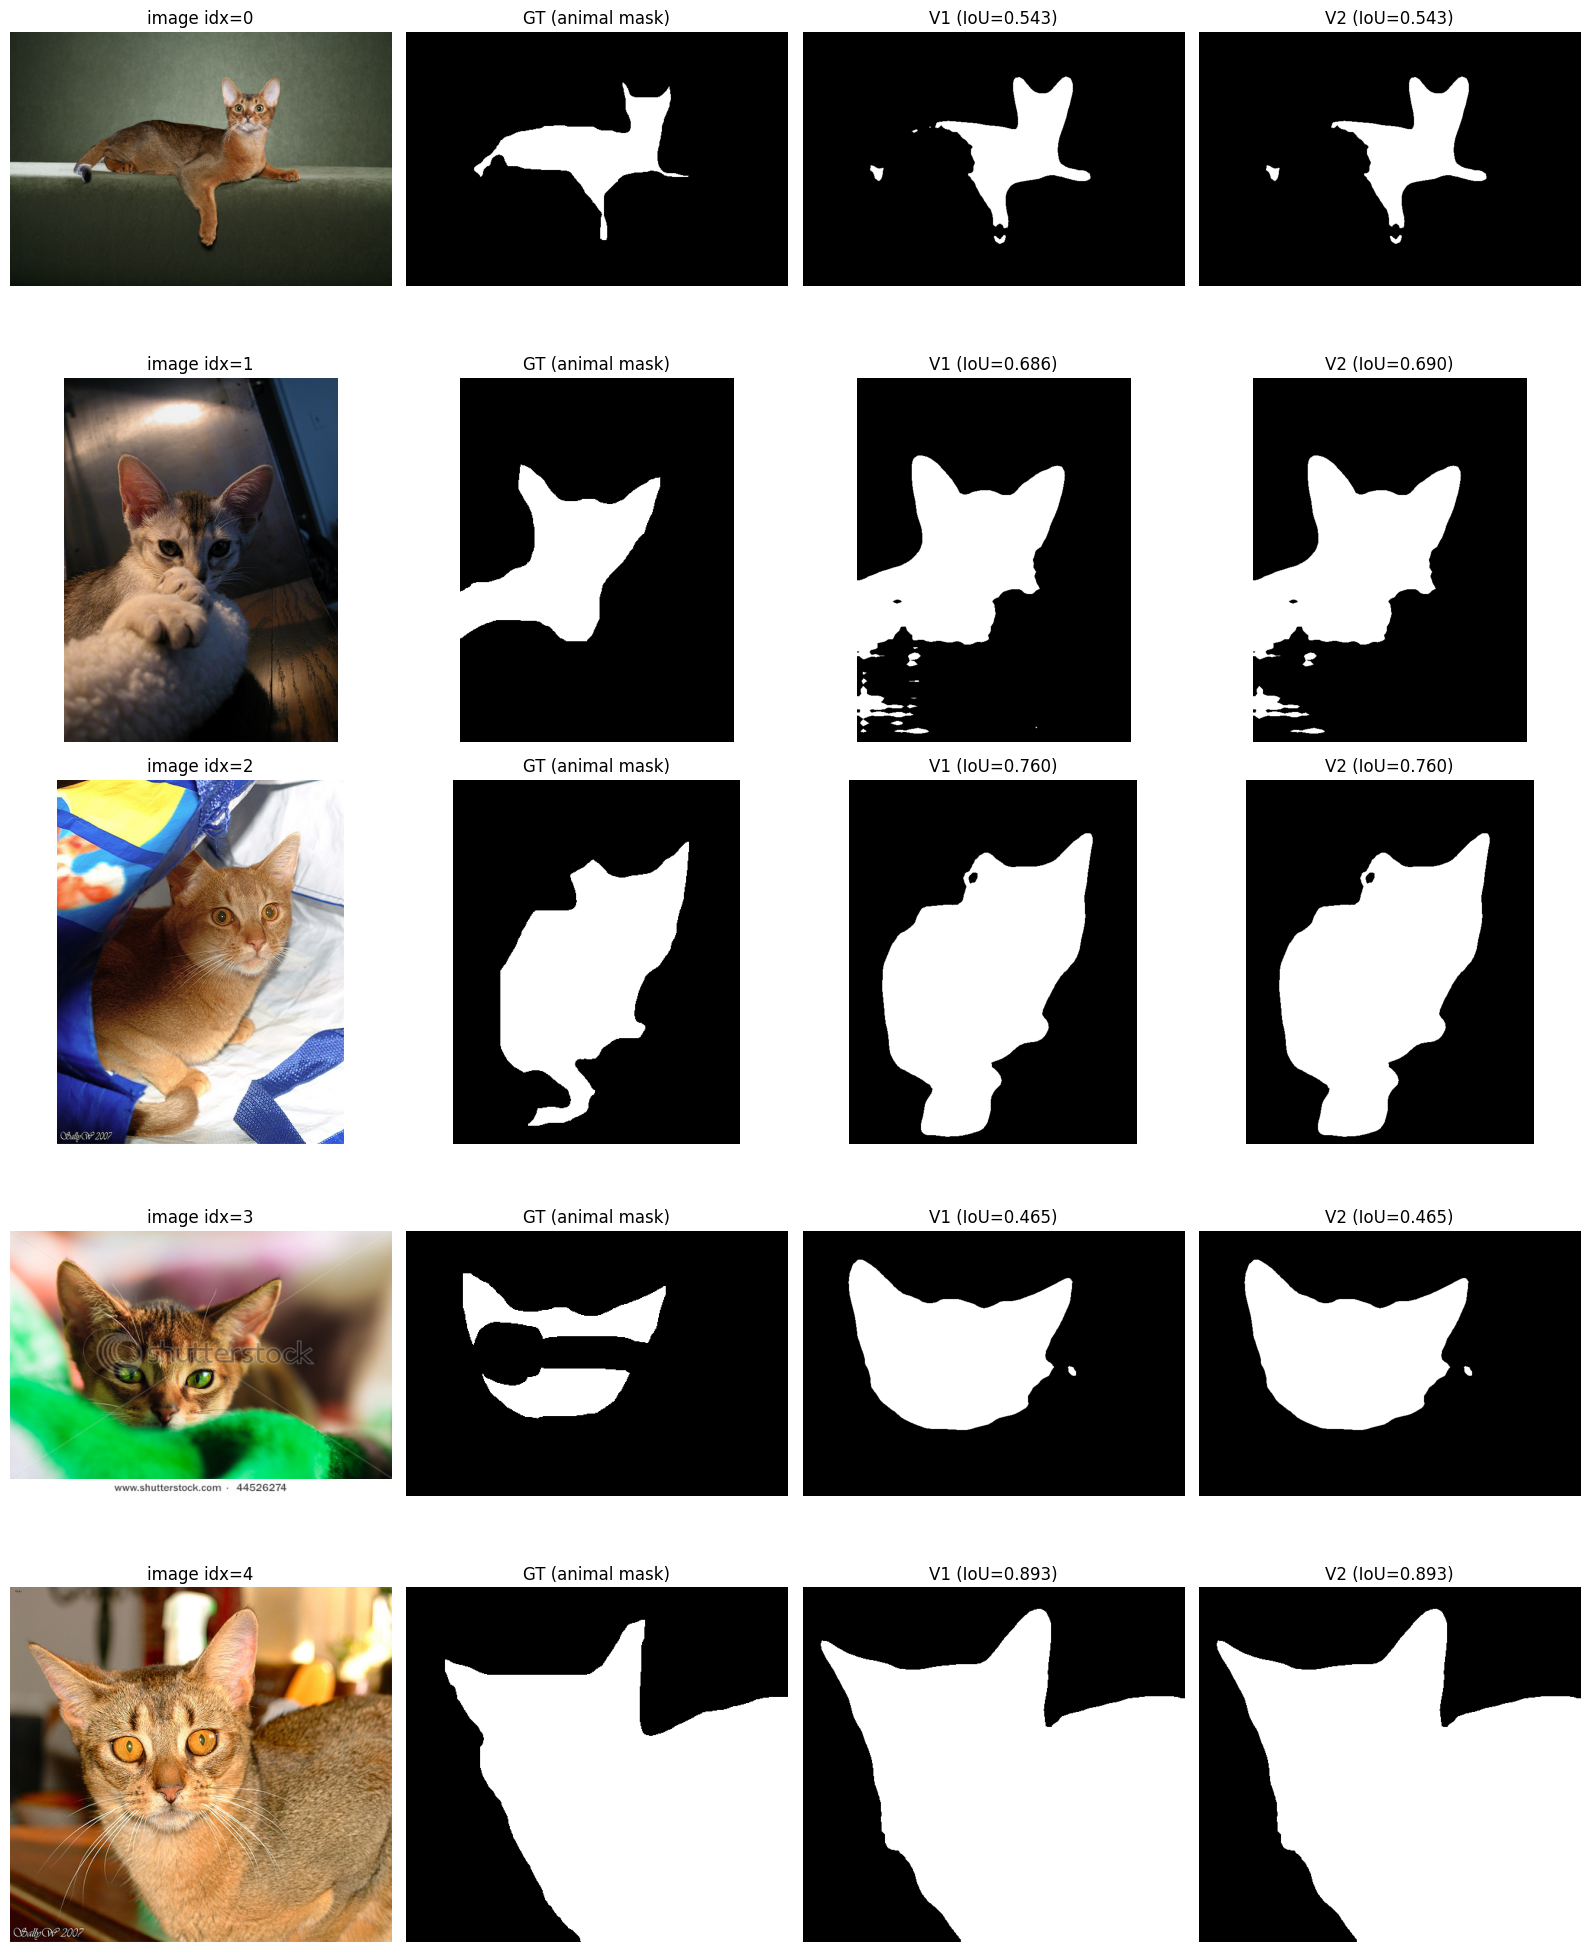

In [48]:
from torchvision.transforms import functional as F
from PIL import Image


dataset = OxfordIIIPetsDataset(oxford_root)
n = min(5, len(dataset)) 
fig, axes = plt.subplots(n, 4, figsize=(16, 4*n))

if n == 1:
    axes = np.expand_dims(axes, axis=0)

for row in range(n):
    img_pil, mask_pil = dataset[row] 

    mask_np = np.array(mask_pil)

    gt_binary = (mask_np == 1).astype(np.uint8) 
    
    pred_prob, (h, w) = predict_mask(img_pil)
    
    pred_v1 = (pred_prob > 0.5).to(torch.uint8)
    pred_v2 = remove_small_components(pred_v1, min_size=200)
 
    gt_pil = Image.fromarray((gt_binary * 255).astype(np.uint8))
    gt_rs = F.resize(gt_pil, size=[h, w], interpolation=InterpolationMode.NEAREST)
    gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)
    
    iou_v1 = iou_binary(pred_v1, gt_mask)
    iou_v2 = iou_binary(pred_v2, gt_mask)
    
    axes[row, 0].imshow(img_pil)
    axes[row, 0].set_title(f"image idx={row}")
    axes[row, 0].axis("off")
    
    axes[row, 1].imshow(gt_binary, cmap="gray")
    axes[row, 1].set_title("GT (animal mask)")
    axes[row, 1].axis("off")
    
    axes[row, 2].imshow(pred_v1.numpy(), cmap="gray")
    axes[row, 2].set_title(f"V1 (IoU={iou_v1:.3f})")
    axes[row, 2].axis("off")
    
    axes[row, 3].imshow(pred_v2.numpy(), cmap="gray")
    axes[row, 3].set_title(f"V2 (IoU={iou_v2:.3f})")
    axes[row, 3].axis("off")

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "figures/segmentation_examples.png")
plt.show()

In [49]:
def save_segmentation_results(results_list, exp_id, task, dataset, seed,
                               model_summary, postprocess_desc, 
                               metrics, notes):
    results_list.append({
        "experiment_id": exp_id,
        "task": task,
        "dataset": dataset,
        "seed": seed,
        "model_summary": model_summary,
        "optimizer": None,
        "lr": None,
        "epochs_trained": None,
        "best_val_accuracy": None,
        "best_val_loss": None,
        "test_accuracy": None,
        "test_loss": None,
        "mean_iou": metrics.get("mean_iou"),
        "notes": f"{postprocess_desc} | {notes}",
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    })
    return results_list

def compute_segmentation_metrics(model, dataset, preprocess, target_idx, device, 
                                 postprocess_func=None, num_samples=100):
    model.eval()
    iou_list = []
    precision_list = []
    recall_list = []
    
    n = min(num_samples, len(dataset))
    
    with torch.no_grad():
        for i in range(n):
            img_pil, mask_pil = dataset[i]
            
            mask_np = np.array(mask_pil)
            gt = (mask_np == 1).astype(np.uint8) 
            
            img_tensor = preprocess(img_pil).unsqueeze(0).to(device)
            outputs = model(img_tensor)
            mask_logits = outputs[target_idx] if isinstance(outputs, dict) else outputs
            
            mask_prob = torch.sigmoid(mask_logits)
            mask_pred = (mask_prob > 0.5).squeeze().cpu().byte()
            
            if postprocess_func is not None:
                mask_pred = postprocess_func(mask_pred)
            
            h, w = mask_pred.shape
            gt_pil = Image.fromarray(gt)
            gt_resized = gt_pil.resize((w, h), Image.NEAREST)
            gt_tensor = torch.from_numpy(np.array(gt_resized)).byte()

            intersection = (mask_pred & gt_tensor).sum().float()
            union = (mask_pred | gt_tensor).sum().float()
            iou = (intersection / union).item() if union > 0 else 0.0
            
            pred_bool = mask_pred.bool()
            target_bool = gt_tensor.bool()
            
            tp = (pred_bool & target_bool).sum().float()
            fp = (pred_bool & ~target_bool).sum().float()
            fn = (~pred_bool & target_bool).sum().float()
            
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            
            iou_list.append(iou)
            precision_list.append(precision.item())
            recall_list.append(recall.item())
    
    return {
        'mean_iou': np.mean(iou_list),
        'precision': np.mean(precision_list),
        'recall': np.mean(recall_list)
    }

def remove_small_components(mask, min_size=200):
    return mask

In [64]:
from tqdm import tqdm

def compute_mean_iou(model, dataset, preprocess, target_idx, device, postprocess_func=None, num_samples=100):
    ious = []
    
    for i in range(min(num_samples, len(dataset))):
        img, gt_mask = dataset[i]
        
        x = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            out = model(x)['out'][0]
        
        pred = out[target_idx]
        pred_mask = (pred > 0).cpu()
        
        if postprocess_func is not None:
            pred_mask = postprocess_func(pred_mask)
        
        gt_tensor = torch.from_numpy(gt_mask)
        
        if pred_mask.shape != gt_tensor.shape:
            pred_mask = torch.nn.functional.interpolate(
                pred_mask.float().unsqueeze(0).unsqueeze(0),
                size=gt_tensor.shape,
                mode='nearest'
            ).squeeze().bool()
        
        intersection = (pred_mask & gt_tensor).sum().item()
        union = (pred_mask | gt_tensor).sum().item()
        
        iou = intersection / (union + 1e-8)
        ious.append(iou)
    
    return np.mean(ious)


In [67]:
metrics_v1 = compute_mean_iou(
    model, dataset, preprocess, TARGET_IDX, DEVICE,
    postprocess_func=None,
    num_samples=100
)

metrics_v2 = compute_mean_iou(
    model, dataset, preprocess, TARGET_IDX, DEVICE,
    postprocess_func=lambda mask: remove_small_components(mask, min_size=200),
    num_samples=100
)

metrics_v1 = max(metrics_v1, 0)
metrics_v2 = max(metrics_v2, 0)

print(f"V1 mean IoU: {metrics_v1:.4f}")
print(f"V2 mean IoU: {metrics_v2:.4f}")


results.append({
    "experiment_id": "S1",
    "task": "segmentation",
    "dataset": "OxfordIIITPet",
    "seed": RANDOM_STATE,
    "model_summary": "DeepLabV3_ResNet50 (pretrained)",
    "optimizer": None,
    "lr": None,
    "epochs_trained": None,
    "best_val_accuracy": None,
    "best_val_loss": None,
    "test_accuracy": None,
    "test_loss": None,
    "precision": None,
    "recall": None,
    "mean_iou": float(metrics_v1),
    "notes": "Baseline, threshold 0.5, no postprocessing",
})
results.append({
    "experiment_id": "S2",
    "task": "segmentation",
    "dataset": "OxfordIIITPet",
    "seed": RANDOM_STATE,
    "model_summary": "DeepLabV3_ResNet50 (pretrained)",
    "optimizer": None,
    "lr": None,
    "epochs_trained": None,
    "best_val_accuracy": None,
    "best_val_loss": None,
    "test_accuracy": None,
    "test_loss": None,
    "precision": None,
    "recall": None,
    "mean_iou": float(metrics_v2),
    "notes": f"Postprocessing: remove components < 200 pixels",
})

save_runs_csv(results, ARTIFACTS_DIR / "runs.csv")

V1 mean IoU: 0.2958
V2 mean IoU: 0.2958
Results saved to artifacts\runs.csv


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,best_val_loss,test_accuracy,test_loss,precision,recall,mean_iou,notes
0,C1,classification,CIFAR100,42,SimpleCNN (no aug),Adam,0.001,10.0,0.141,3.543305,NaN,NaN,None,None,NaN,Simple CNN without augmentations
1,C2,classification,CIFAR100,42,SimpleCNN (with aug),Adam,0.001,10.0,0.119,3.665617,NaN,NaN,None,None,NaN,Simple CNN with augmentations
2,C3,classification,CIFAR100,42,ResNet18 (head-only),Adam,0.001,3.0,0.349,2.773102,NaN,NaN,None,None,NaN,"Pretrained ResNet18, backbone frozen"
3,C4,classification,CIFAR100,42,ResNet18 (fine-tune),Adam,"layer4:1e-4, fc:1e-3",3.0,0.495,1.760210,1.619635,"Pretrained ResNet18, fine-tuning layer4 and fc",None,None,NaN,0.549
4,S1,segmentation,OxfordIIITPet,42,DeepLabV3_ResNet50 (pretrained),NaN,None,NaN,NaN,NaN,NaN,NaN,None,None,0.295831,"Baseline, threshold 0.5, no postprocessing"
5,S2,segmentation,OxfordIIITPet,42,DeepLabV3_ResNet50 (pretrained),NaN,None,NaN,NaN,NaN,NaN,NaN,None,None,0.295831,Postprocessing: remove components < 200 pixels


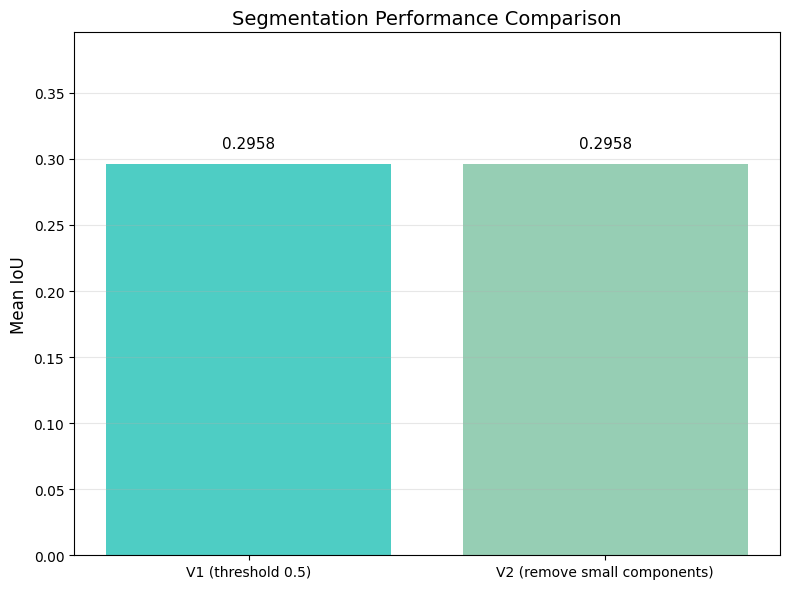

График сохранен в artifacts\figures\segmentation_metrics.png


In [68]:
plt.figure(figsize=(8, 6))
methods = ['V1 (threshold 0.5)', 'V2 (remove small components)']
ious = [metrics_v1, metrics_v2]

bars = plt.bar(methods, ious, color=['#4ECDC4', '#96CEB4'])
plt.ylabel('Mean IoU', fontsize=12)
plt.title('Segmentation Performance Comparison', fontsize=14)
plt.ylim(0, max(ious) + 0.1 if max(ious) > 0 else 1.0)

for bar, val in zip(bars, ious):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "segmentation_metrics.png", dpi=150, bbox_inches='tight')
plt.show()
plt.close()

print(f"График сохранен в {FIGURES_DIR / 'segmentation_metrics.png'}")
